In [43]:
# Capstone Project: EDA and Baseline Model

## Predicting Short-Term Stock Returns Using Technical and Fundamental Indicators

### Research Question
#Can short-term to medium-term stock returns be predicted using historical price behavior, trading volume patterns, and company fundamentals?



In [44]:
!pip install yfinance

In [45]:
# ===============================
# DATA MANIPULATION
# ===============================
import yfinance as yf
import pandas as pd
import numpy as np

# ===============================
# VISUALIZATION
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# Professional plot styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10,6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# ===============================
# MACHINE LEARNING
# ===============================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

print("All libraries successfully imported.")

All libraries successfully imported.


In [46]:
# Define diversified large-cap stock 
tickers = [
    "AAPL","MSFT","NVDA","GOOGL","META","AMZN","ADBE","CRM",
    "JPM","BAC","GS","MS","WFC","C","BLK",
    "WMT","COST","HD","LOW","MCD","NKE",
    "CAT","DE","HON","GE","BA",
    "JNJ","UNH","PFE","MRK",
    "XOM","CVX","COP"
]

start_date = "2023-01-01"
end_date = "2025-12-31"

print("Downloading price data from Yahoo Finance...")

price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    group_by="ticker",
    auto_adjust=True,
    progress=False
)

print("Download complete.")

Download complete.


In [47]:
frames = []

print("Beginning feature engineering...")

for ticker in tickers:
    
    df = price_data[ticker].copy()
    df["ticker"] = ticker
    
    # Daily return
    df["return_1d"] = df["Close"].pct_change()
    
    # 5-day return
    df["return_5d"] = df["Close"].pct_change(5)
    
    # Rolling volatility
    df["vol_10d"] = df["return_1d"].rolling(10).std()
    df["vol_20d"] = df["return_1d"].rolling(20).std()
    
    # Volume anomaly (z-score)
    df["volume_z"] = (
        df["Volume"] - df["Volume"].rolling(20).mean()
    ) / df["Volume"].rolling(20).std()
    
    # Momentum
    df["momentum_10d"] = df["Close"] / df["Close"].shift(10) - 1
    
    # Forward 5-day return (prediction target)
    df["target_5d"] = df["Close"].pct_change(5).shift(-5)
    
    frames.append(df.reset_index())

price_features = pd.concat(frames, ignore_index=True)

print("Feature engineering complete.")
print("Current dataset shape:", price_features.shape)

Beginning feature engineering...
Feature engineering complete.
Current dataset shape: (24783, 14)


In [48]:
print("Retrieving fundamental data...")

fundamental_rows = []

for ticker in tickers:
    info = yf.Ticker(ticker).info
    
    fundamental_rows.append({
        "ticker": ticker,
        "market_cap": info.get("marketCap"),
        "pe_ratio": info.get("trailingPE"),
        "forward_pe": info.get("forwardPE"),
        "price_to_book": info.get("priceToBook"),
        "beta": info.get("beta"),
        "sector": info.get("sector")
    })

fundamentals = pd.DataFrame(fundamental_rows)

print("Fundamental data collected.")

Retrieving fundamental data...
Fundamental data collected.


In [49]:
print("Merging price and fundamental data...")

data = price_features.merge(fundamentals, on="ticker", how="left")

# Remove duplicates
duplicates = data.duplicated().sum()
print("Duplicate rows detected:", duplicates)
data = data.drop_duplicates()

# Drop rows missing key engineered values
data = data.dropna(subset=[
    "return_1d","return_5d","vol_10d",
    "vol_20d","volume_z","momentum_10d",
    "target_5d"
])

print("Final cleaned dataset shape:", data.shape)

Merging price and fundamental data...
Duplicate rows detected: 0
Final cleaned dataset shape: (23958, 20)


Visualizing distribution of target variable...


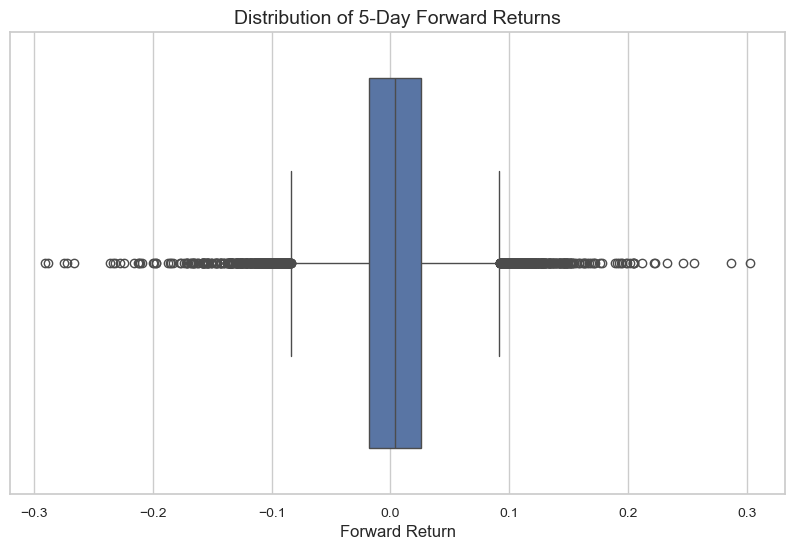

Outliers capped at 1st and 99th percentiles.


In [50]:
print("Visualizing distribution of target variable...")

plt.figure()
sns.boxplot(x=data["target_5d"])
plt.title("Distribution of 5-Day Forward Returns")
plt.xlabel("Forward Return")
plt.show()

# Winsorize extreme values
lower = data["target_5d"].quantile(0.01)
upper = data["target_5d"].quantile(0.99)

data["target_5d"] = np.clip(data["target_5d"], lower, upper)

print("Outliers capped at 1st and 99th percentiles.")

Generating correlation heatmap...


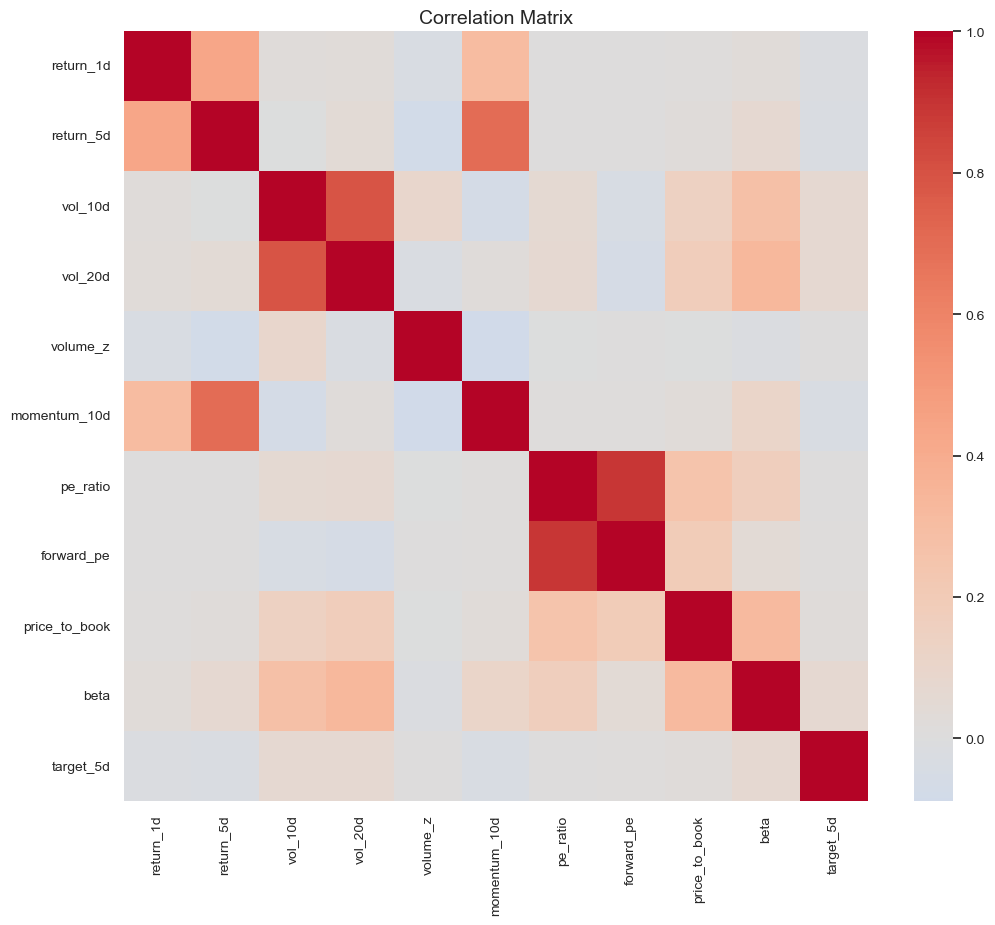

In [51]:
feature_cols = [
    "return_1d","return_5d",
    "vol_10d","vol_20d",
    "volume_z","momentum_10d",
    "pe_ratio","forward_pe",
    "price_to_book","beta"
]

print("Generating correlation heatmap...")

plt.figure(figsize=(12,10))
sns.heatmap(
    data[feature_cols + ["target_5d"]].corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

Performing PCA on technical indicators...


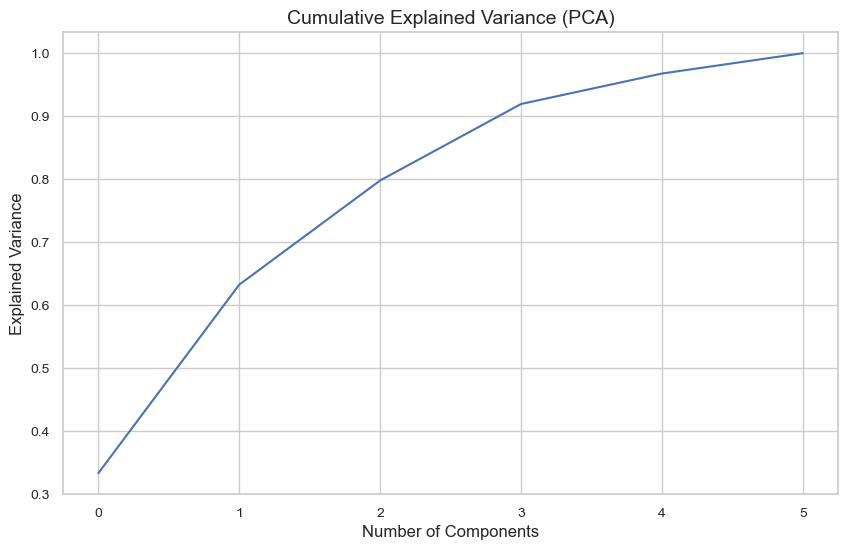

Total variance explained by first 2 components: 0.6324092789193747


In [52]:
print("Performing PCA on technical indicators...")

tech_cols = [
    "return_1d","return_5d",
    "vol_10d","vol_20d",
    "volume_z","momentum_10d"
]

scaler = StandardScaler()
X_tech_scaled = scaler.fit_transform(data[tech_cols])

pca = PCA()
pca.fit(X_tech_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Cumulative Explained Variance (PCA)")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.show()

print("Total variance explained by first 2 components:",
      np.sum(pca.explained_variance_ratio_[:2]))

In [53]:
print("Splitting data into training and testing sets (time-based split)...")

data = data.sort_values("Date")
split_date = "2025-01-01"

train = data[data["Date"] < split_date]
test = data[data["Date"] >= split_date]

X_train = train[feature_cols]
y_train = train["target_5d"]

X_test = test[feature_cols]
y_test = test["target_5d"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Splitting data into training and testing sets (time-based split)...
Training set size: (15906, 10)
Testing set size: (8052, 10)


In [54]:
print("Two evaluation metrics are used:\n"
      "\n"
      "1. Mean Squared Error (MSE)\n"
      "2. R-squared (R²)\n"
      "\n"
      "MSE is selected as the primary evaluation metric because:\n"
      "\n"
      "- It penalizes larger prediction errors more heavily.\n"
      "- It directly measures prediction accuracy in squared return space.\n"
      "- It is the standard loss function for regression models.\n"
      "\n"
      "R² is included as a complementary metric to measure the proportion of variance explained by the model.")

Two evaluation metrics are used:

1. Mean Squared Error (MSE)
2. R-squared (R²)

MSE is selected as the primary evaluation metric because:

- It penalizes larger prediction errors more heavily.
- It directly measures prediction accuracy in squared return space.
- It is the standard loss function for regression models.

R² is included as a complementary metric to measure the proportion of variance explained by the model.


In [55]:
print("Training baseline OLS model...")

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

ols_preds = ols_model.predict(X_test_scaled)

ols_mse = mean_squared_error(y_test, ols_preds)
ols_r2 = r2_score(y_test, ols_preds)

print("OLS MSE:", ols_mse)
print("OLS R²:", ols_r2)

print("Ordinary Least Squares (OLS) regression is selected as the baseline model because:\n"
      "\n"
      "- It provides an interpretable linear benchmark.\n"
      "- It allows direct coefficient interpretation.\n"
      "- It establishes a performance floor before applying regularization.\n"
      "- It is the standard starting point for financial return modeling.\n"
      "\n"
      "More complex models (Ridge and Lasso) are introduced to evaluate whether regularization improves generalization performance.")

Training baseline OLS model...
OLS MSE: 0.0015620968032715034
OLS R²: 0.007338660656788787
Ordinary Least Squares (OLS) regression is selected as the baseline model because:

- It provides an interpretable linear benchmark.
- It allows direct coefficient interpretation.
- It establishes a performance floor before applying regularization.
- It is the standard starting point for financial return modeling.

More complex models (Ridge and Lasso) are introduced to evaluate whether regularization improves generalization performance.


In [56]:
print("Training Ridge and Lasso with cross-validation...")

alphas = np.logspace(-4, 4, 50)

ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_train_scaled, y_train)

lasso_model = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

ridge_preds = ridge_model.predict(X_test_scaled)
lasso_preds = lasso_model.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

lasso_mse = mean_squared_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)

print("Ridge MSE:", ridge_mse)
print("Ridge R²:", ridge_r2)
print("Lasso MSE:", lasso_mse)
print("Lasso R²:", lasso_r2)

Training Ridge and Lasso with cross-validation...
Ridge MSE: 0.0015621143913519334
Ridge R²: 0.007327484007915497
Lasso MSE: 0.001572433454225885
Lasso R²: 0.0007700576360216704


Model comparison table:
   Model       MSE        R2
0    OLS  0.001562  0.007339
1  Ridge  0.001562  0.007327
2  Lasso  0.001572  0.000770


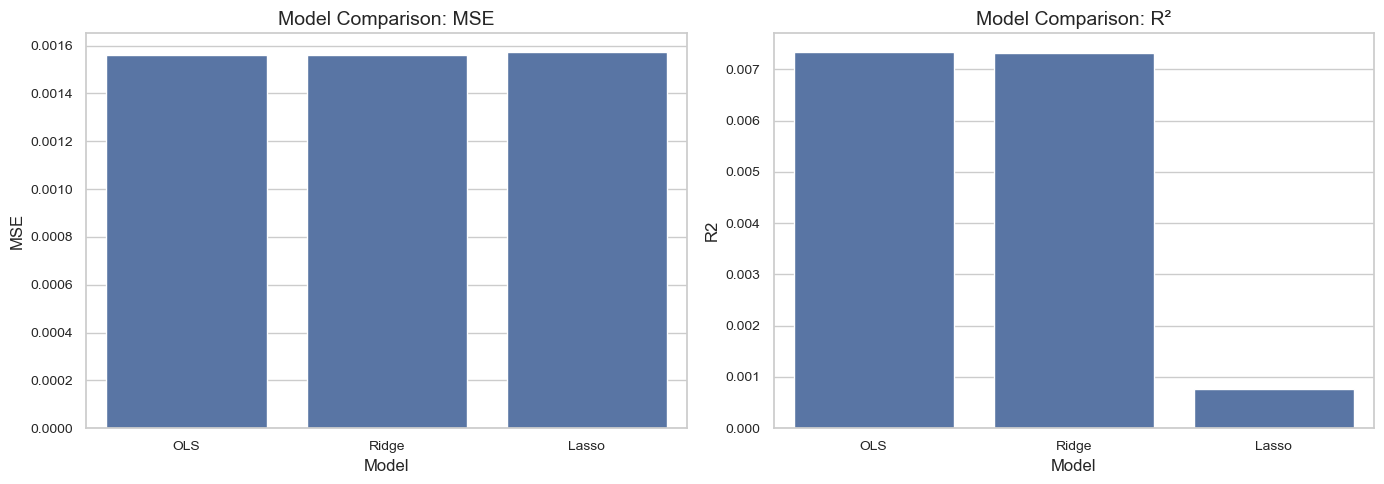

If deployed across 30 stocks daily, even a 0.7% explanatory signal could support modest risk-adjusted alpha if transaction costs are controlled.


In [57]:
model_results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "MSE": [ols_mse, ridge_mse, lasso_mse],
    "R2": [ols_r2, ridge_r2, lasso_r2]
})

print("Model comparison table:")
print(model_results)

fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.barplot(data=model_results, x="Model", y="MSE", ax=ax[0])
ax[0].set_title("Model Comparison: MSE")

sns.barplot(data=model_results, x="Model", y="R2", ax=ax[1])
ax[1].set_title("Model Comparison: R²")

plt.tight_layout()
plt.show()

print ("If deployed across 30 stocks daily, even a 0.7% explanatory signal could support modest risk-adjusted alpha if transaction costs are controlled.")

Analyzing coefficient stability...
                    OLS     Ridge     Lasso
Feature                                    
return_1d     -0.000065 -0.000109 -0.000000
return_5d     -0.000578 -0.000377 -0.000000
vol_10d        0.001157  0.000748  0.000000
vol_20d        0.000623  0.000644  0.000000
volume_z      -0.000077 -0.000020  0.000000
momentum_10d  -0.000639 -0.000343 -0.000000
pe_ratio      -0.002985 -0.000254  0.000000
forward_pe     0.003006  0.000341  0.000000
price_to_book -0.000133  0.000095  0.000000
beta           0.002948  0.001589  0.001015


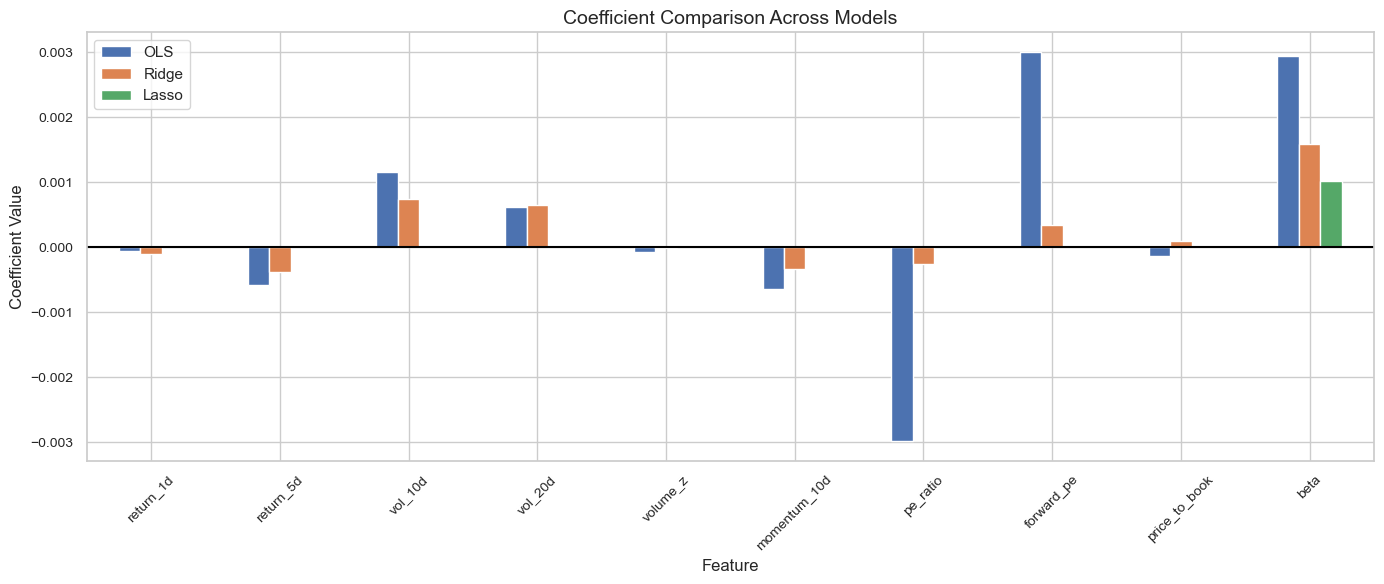

In [58]:
print("Analyzing coefficient stability...")

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "OLS": ols_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
}).set_index("Feature")

print(coef_df)

coef_df.plot(kind="bar", figsize=(14,6))
plt.axhline(0, color='black')
plt.title("Coefficient Comparison Across Models")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
from sklearn.linear_model import Ridge  # Import the Ridge class from scikit-learn
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

print("Performing TimeSeriesSplit validation on Ridge...")

tscv = TimeSeriesSplit(n_splits=5)
tscv_mse = []

for train_idx, val_idx in tscv.split(X_train_scaled):
    X_t, X_v = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = Ridge(alpha=ridge_model.alpha_)
    model.fit(X_t, y_t)
    preds = model.predict(X_v)
    tscv_mse.append(mean_squared_error(y_v, preds))

print("Average TimeSeries CV MSE:", np.mean(tscv_mse))

Performing TimeSeriesSplit validation on Ridge...
Average TimeSeries CV MSE: 0.001207005148630591


In [60]:
print("## Model Evaluation and Interpretation\n"
      "\n"
      "Out-of-sample R² values are approximately 0.007 (0.7%).\n"
      "\n"
      "While this may appear small, short-horizon stock returns are known to be highly noisy and difficult to predict.\n"
      "\n"
      "In financial modeling:\n"
      "\n"
      "- Low R² values are common.\n"
      "- Even small predictive signals can be economically meaningful.\n"
      "- Market efficiency limits large explanatory power.\n"
      "\n"
      "MSE remains stable across OLS and Ridge, indicating that regularization does not substantially improve predictive accuracy in this linear framework.\n"
      "\n"
      "Lasso shrinks most coefficients toward zero, suggesting weak linear relationships between predictors and short-term returns.")

## Model Evaluation and Interpretation

Out-of-sample R² values are approximately 0.007 (0.7%).

While this may appear small, short-horizon stock returns are known to be highly noisy and difficult to predict.

In financial modeling:

- Low R² values are common.
- Even small predictive signals can be economically meaningful.
- Market efficiency limits large explanatory power.

MSE remains stable across OLS and Ridge, indicating that regularization does not substantially improve predictive accuracy in this linear framework.

Lasso shrinks most coefficients toward zero, suggesting weak linear relationships between predictors and short-term returns.
